In [1]:
from langgraph.graph import StateGraph, END, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv

from langchain_core.messages import RemoveMessage

load_dotenv()

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
LLM = ChatGroq(model="openai/gpt-oss-20b", temperature=0.5)

In [3]:
def chat_node(state: MessagesState):
    response = LLM.invoke(state['messages'])
    return {'messages': [response]}

def clean_up(state: MessagesState):
    msg = state['messages']
    
    # now suppose we are checking for the recent messages of 10
    if len(msg)>10:
        #agar 10 se jada msg aagye toh usmye se 6 ko hata do and 4 hi rakho.
        #removin the 6 messages from the state
        to_remove =  msg[:6]
        return {'messages': [RemoveMessage(id=m.id) for m in to_remove]}
        
    return{}

In [4]:
#building the graph
graph = StateGraph(MessagesState)
graph.add_node("chat_node", chat_node)
graph.add_node("clean_up", clean_up)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node", "clean_up")
graph.add_edge("clean_up", END)

memory = InMemorySaver()

Summarizer = graph.compile(checkpointer=memory)



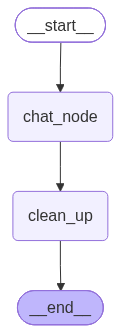

In [5]:
from IPython.display import Image
Image(Summarizer.get_graph().draw_mermaid_png())

In [6]:
#creating our first thread for this chat
config1 = {"configurable": {"thread_id": "t1"}}

In [10]:
Summarizer.invoke({"messages": [{"role": "user", "content": "hi how are you?"}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "i m learning"}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "what is langchain?"}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "what is gen ai? "}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "gen ai vs agentic ai? "}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "what are ai agents? "}]}, config1)
Summarizer.invoke({"messages": [{"role": "user", "content": "what is agents vs aiagents?"}]}, config1)

{'messages': [AIMessage(content='## Generative AI (Gen\u202fAI) – The Big Picture\n\n| Term | What it means | Why it matters |\n|------|----------------|----------------|\n| **Generative AI** | AI systems that *create* new content—text, images, audio, video, code, data, or even 3‑D models—rather than just *recognizing* or *classifying* existing data. | It turns data into *creative* or *useful* artifacts, opening new business models, automation, and personalization. |\n\n---\n\n### 1. How It Works (High‑Level)\n\n| Step | Description | Key Tech |\n|------|-------------|----------|\n| **1️⃣ Training Data** | Massive corpora (text, images, audio, etc.). | Web‑scraped text, image datasets, music libraries. |\n| **2️⃣ Model Architecture** | Usually a *transformer* (e.g., GPT, Diffusion, Stable Diffusion, AudioLDM). | Self‑attention, large‑scale parallelism. |\n| **3️⃣ Learning Objective** | Predict next token, denoise, or reconstruct data. | Autoregressive (language), diffusion (images), co

# So for above we have done the cleanup since we got 4 ai messages for this